# Evaluating a Classification Model

After training a classification model, we need to evaluate how well it performs on new, unseen data.  
This helps us understand whether the model has learned to generalize — not just memorize the training data.

There are several key metrics used to evaluate classification models:
* Confusion Matrix
* Accuracy, Precision, Recall, F1
* ROC, AUC

### 🧠 Why is evaluation important?

Even if your model shows high accuracy on training data, it might:
- Perform poorly on new data (overfitting),
- Be biased toward certain classes (class imbalance),
- Or give a false sense of confidence.

**Model evaluation helps us detect and fix these issues.**

---
# Import Data and Build Pipeline

In [6]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [8]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    StandardScaler(), LogisticRegression(solver="liblinear", random_state=1)
)
pipe.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


# ✅ Accuracy
- The simplest metric.
- It tells us **what proportion of predictions were correct**.
- Formula:  
$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
$$

> 📌 Good for **balanced datasets**, but can be misleading if the classes are imbalanced.

In [14]:
y_pred = pipe.predict(X_test)
print("Accuracy of Test: %.3f" % pipe.score(X_test, y_test))

Accuracy of Test: 0.965


---
# ✅ Confusion Matrix
- A table that compares actual labels with predicted labels.
- It shows **how many were correctly or incorrectly classified** for each class.
- Especially helpful for **multi-class classification**.


In [15]:
from sklearn.metrics import confusion_matrix

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[ 60   4]
 [  2 105]]


### Accuracy, Precision, Recall, and F1 Score

When evaluating a classification model, especially on imbalanced datasets, it’s important to consider multiple metrics beyond just accuracy.

---

**🔹 Accuracy**  
- The ratio of correctly predicted samples (both true positives and true negatives).  
- Formula:  
  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$

---

**🔹 Precision**  
- Out of all samples predicted as positive, how many were actually positive?  
- This tells us how much "noise" (false positives) is in our positive predictions.  
- Formula:  
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$

---

**🔹 Recall** (Sensitivity or True Positive Rate)  
- Out of all actual positive samples, how many did the model correctly identify?  
- This shows the model’s ability to find all positive cases.  
- Formula:  
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$

---

**🔹 F1 Score**  
- The harmonic mean of precision and recall.  
- It balances both metrics, especially useful when the dataset is imbalanced.  
- Formula:  
  $$
  \text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
  $$

---
### Summary:
`Precision, Recall, and F1-Score` These metrics are especially useful when class distributions are uneven.

- **Precision**: How many of the predicted positives are actually correct?
- **Recall**: How many of the actual positives did the model catch?
- **F1-Score**: The harmonic mean of precision and recall. A balanced score.

We'll explore these in later steps with `classification_report()`.

---

### ⚠️ Why Accuracy Can Be Misleading (Imbalanced Classes)

In imbalanced datasets, accuracy can be very high even if the model is **not actually performing well**.

📌 Example:  
Suppose a rare disease affects only **0.1%** of the population.  
If a model predicts "no disease" for every patient, its accuracy is **99.9%**,  
but it **fails to detect any actual cases** — which is dangerous in real life.

In such cases, **F1 Score** gives a better picture of model performance, as it considers both precision and recall.

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Positive Predictive Value: %.3f" % precision_score(y_true=y_test, y_pred=y_pred))
print(
    "Sensitivity(=True Positive Rate): %.3f"
    % recall_score(y_true=y_test, y_pred=y_pred)
)
print("Accuracy: %.3f" % pipe.score(X_test, y_test))
print("F1 Score: %.3f" % f1_score(y_true=y_test, y_pred=y_pred))

Positive Predictive Value: 0.963
Sensitivity(=True Positive Rate): 0.981
Accuracy: 0.965
F1 Score: 0.972


# ✅ classification_report

`classification_report` provides a convenient summary of key evaluation metrics for each class in a classification problem.

It includes:
### Precision, Recall, F1-score, support
- **Precision**: How many of the predicted samples for a class were actually correct?
- **Recall**: How many of the actual samples from a class were correctly predicted?
- **F1-score**: The harmonic mean of precision and recall.
- **Support**: The number of actual samples for each class (i.e. how many test samples belong to that class).

### Average types explained
- **macro**:  
  - This is the **unweighted average** of the scores for each class.  
  - All classes are treated equally, regardless of how many samples each class has.
- **weighted**:  
  - This is the **average weighted by the number of samples** in each class.  
  - Classes with more samples have more influence on the final score.
- **accuracy**:  
  - The overall percentage of correctly predicted samples.  
---

📌 Tip:  
When classes are imbalanced, pay close attention to **precision, recall, and F1-score** rather than just overall accuracy.


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Malignant 0", "Benign 1"]))

              precision    recall  f1-score   support

 Malignant 0       0.97      0.94      0.95        64
    Benign 1       0.96      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



# ✅ ROC and AUC

When evaluating classification models — especially binary classifiers — we often use **ROC curves** and **AUC scores** to understand how well the model distinguishes between classes.

**🔹 ROC (Receiver Operating Characteristic Curve)**  
- A plot that shows the relationship between:
  - **True Positive Rate (TPR)** → also called **Recall**
  - **False Positive Rate (FPR)**
- ROC curves are useful for comparing classification models across all threshold values.
- The closer the curve hugs the top-left corner, the better the model performs.

**🔹 AUC (Area Under the Curve)**  
- The **area under the ROC curve**.
- It summarizes the model’s ability to distinguish between classes.
- Values range from:
  - **0.5** → no better than random guessing
  - **1.0** → perfect classifier
- The closer the AUC is to 1, the better the model.

---

📌 Tip for students:  
Use ROC and AUC when:
- You're dealing with **imbalanced datasets**.
- You care about **ranking or threshold tuning**, not just accuracy.

We’ll explore how to draw the ROC curve and calculate AUC using `roc_curve` and `roc_auc_score` from scikit-learn.


In [ ]:
from sklearn.metrics import roc_curve, auc

probas = pipe.fit(X_test, y_test).predict_proba(X_test)

fpr, tpr, thresholds = roc_curve(y_test, probas[:, 1], pos_label=1)
fpr, tpr, thresholds

(array([0.      , 0.      , 0.      , 0.015625, 0.015625, 0.03125 ,
        0.03125 , 1.      ]),
 array([0.        , 0.00934579, 0.95327103, 0.95327103, 0.98130841,
        0.98130841, 1.        , 1.        ]),
 array([           inf, 9.99999908e-01, 8.14788424e-01, 7.68524204e-01,
        6.68876254e-01, 6.20070112e-01, 5.04803673e-01, 2.81312139e-10]))

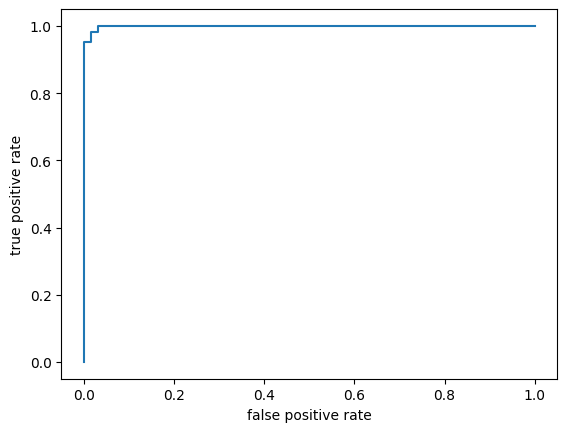

In [82]:
plt.plot(fpr, tpr)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.show()

In [83]:
roc_auc = auc(fpr, tpr)
print("AUC : %.3f" % roc_auc)

AUC : 0.999
